## EDA 总结报告（Telco Customer Churn）

---

### 一、项目背景与目标

> 本分析基于某电信公司 7043 名客户的订阅数据，共 21 个字段，旨在识别客户流失（Churn）的关键驱动因素，为后续建模与业务策略提供数据依据。

---

### 二、数据概览

| 指标 | 数值 |
|------|------|
| 样本总量 | 7,043 |
| 特征数量 | 21（含 1 个目标变量） |
| 数值型特征 | 4 个（`SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`） |
| 分类型特征 | 17 个（含 `customerID`） |
| 目标变量 | `Churn`（Yes / No） |

---

### 三、数据质量检查

#### 3.1 缺失值处理
- `TotalCharges` 原始类型为 `object`，经排查发现 **11 条记录**缺失，对应 `tenure = 0` 的首月新用户。
- **处理方式**：使用 `pd.to_numeric(errors='coerce')` 将非数字、空格、空字符串等转为 `NaN`，并以 `MonthlyCharges` 填充（首月总消费 = 首月月费）。
- 其余字段均无缺失值。
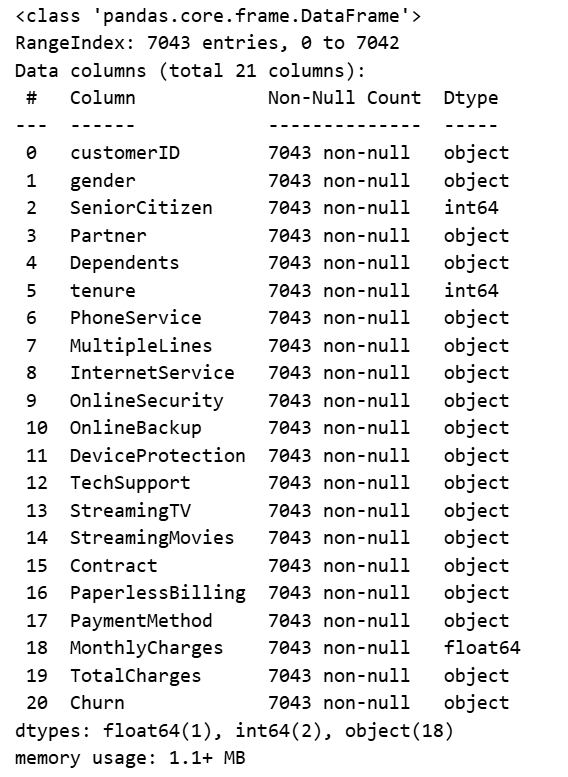
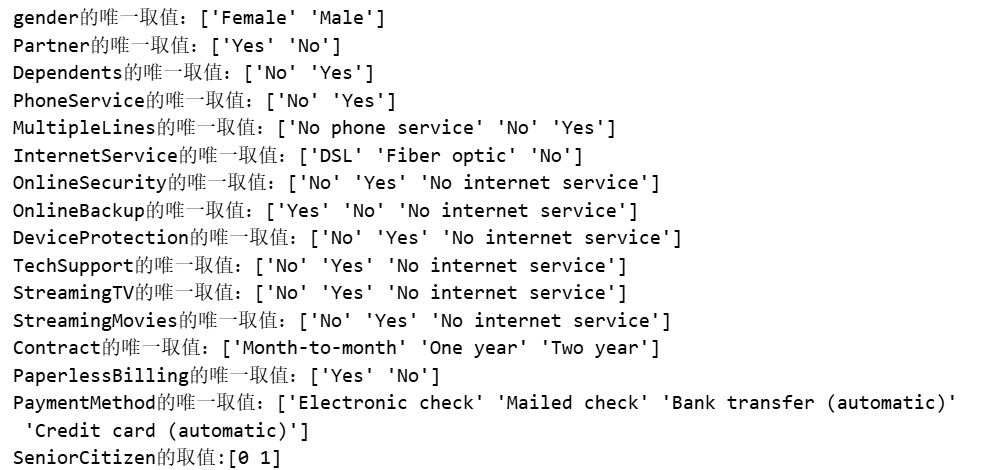

#### 3.2 检查ID是否符合XXXX（0-9数字）-XXXXX（大写字母）格式
- customerID都符合这个格式，且没有重复ID

#### 3.3 异常值检查
- 数值型字段通过 `describe()` 与业务逻辑校验，**无负数、无极端异常值**。

---

### 四、单变量分析

#### 4.1 目标变量分布
- **未流失（No）**：约 73.4%
- **已流失（Yes）**：约 26.6%
- **结论**：存在轻度类别不平衡，后续建模需考虑采样策略或调整类别权重。

#### 4.2 数值型特征分布
| 特征 | 分布特征 | 业务解读 |
|------|---------|---------|
| `tenure` | 双峰分布，0-5 个月与 60-72 个月用户较多 | 存在明显的"新用户"与"老用户"两极分化 |
| `MonthlyCharges` | 右偏分布，集中在 20-30 与 70-100 两个区间 | 对应基础套餐与高端套餐（含光纤/流媒体） |
| `TotalCharges` | 右偏分布，与 `tenure` 高度相关（r ≈ 0.8+） | 累计消费主要由在网时长驱动 |
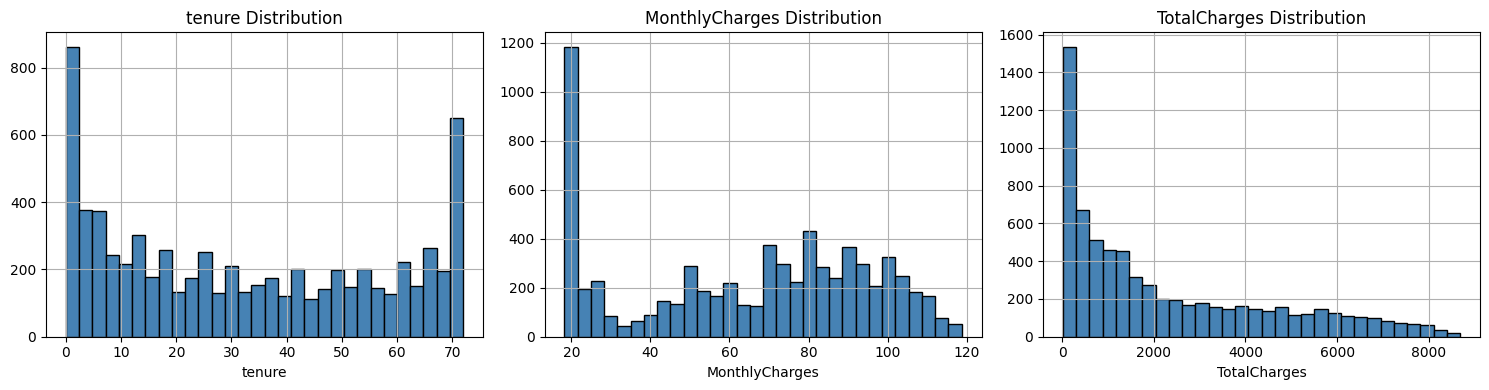

#### 4.3 关键类别型特征
- `Contract`：Month-to-month 占比最高（约 55%），Two year 用户最少。
- `InternetService`：Fiber optic 与 DSL 用户占比相当，约 21% 用户无网络服务。
- `PaymentMethod`：Electronic check 用户占比约 33.6%，为最大支付方式群体。
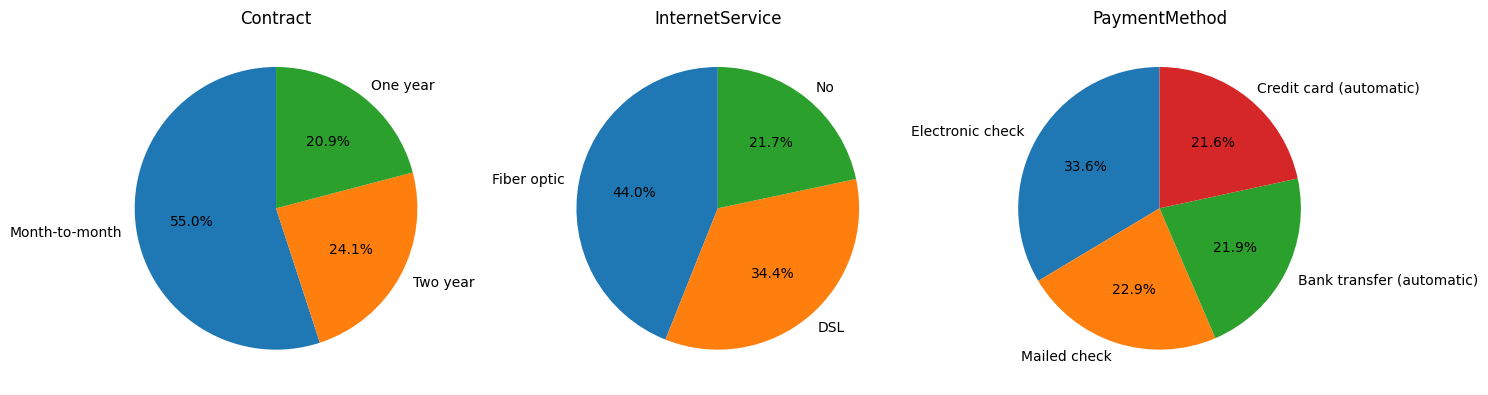

---

### 五、多变量分析（特征与流失的关系）

#### 5.1 数值型特征 vs Churn
- **`tenure` 与 Churn 呈负相关**：流失用户的中位在网时长显著低于留存用户（约 10 个月 vs 38 个月）。
- **`MonthlyCharges` 与 Churn 呈正相关**：流失用户的月费中位数更高（约 74 元 vs 43 元）。
- **`TotalCharges` 与 Churn 呈负相关**：流失用户累计消费更低（用的时间短，自然累计少）。
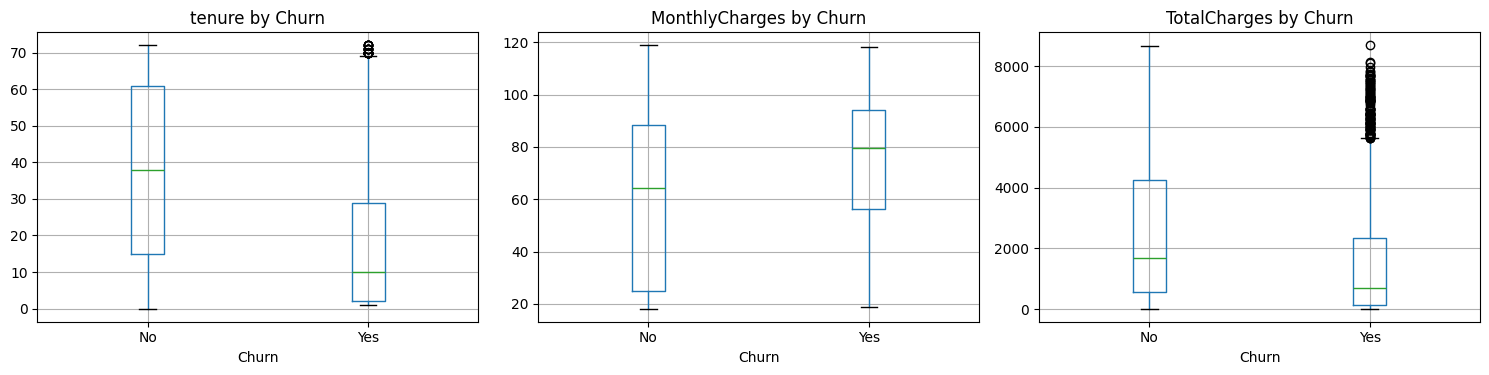

#### 5.2 类别型特征 vs Churn（流失率排序）
| 特征 | 高流失率群体 | 低流失率群体 |
|------|------------|------------|
| `Contract` | **Month-to-month（约 42%）** | Two year（约 3%） |
| `InternetService` | **Fiber optic（约 42%）** | No Internet Service（约 7%） |
| `PaymentMethod` | **Electronic check（约 45%）** | Credit card / Bank transfer（约 15%） |
| `OnlineSecurity` | **No（约 42%）** | Yes（约 15%） |
| `TechSupport` | **No（约 41%）** | Yes（约 15%） |
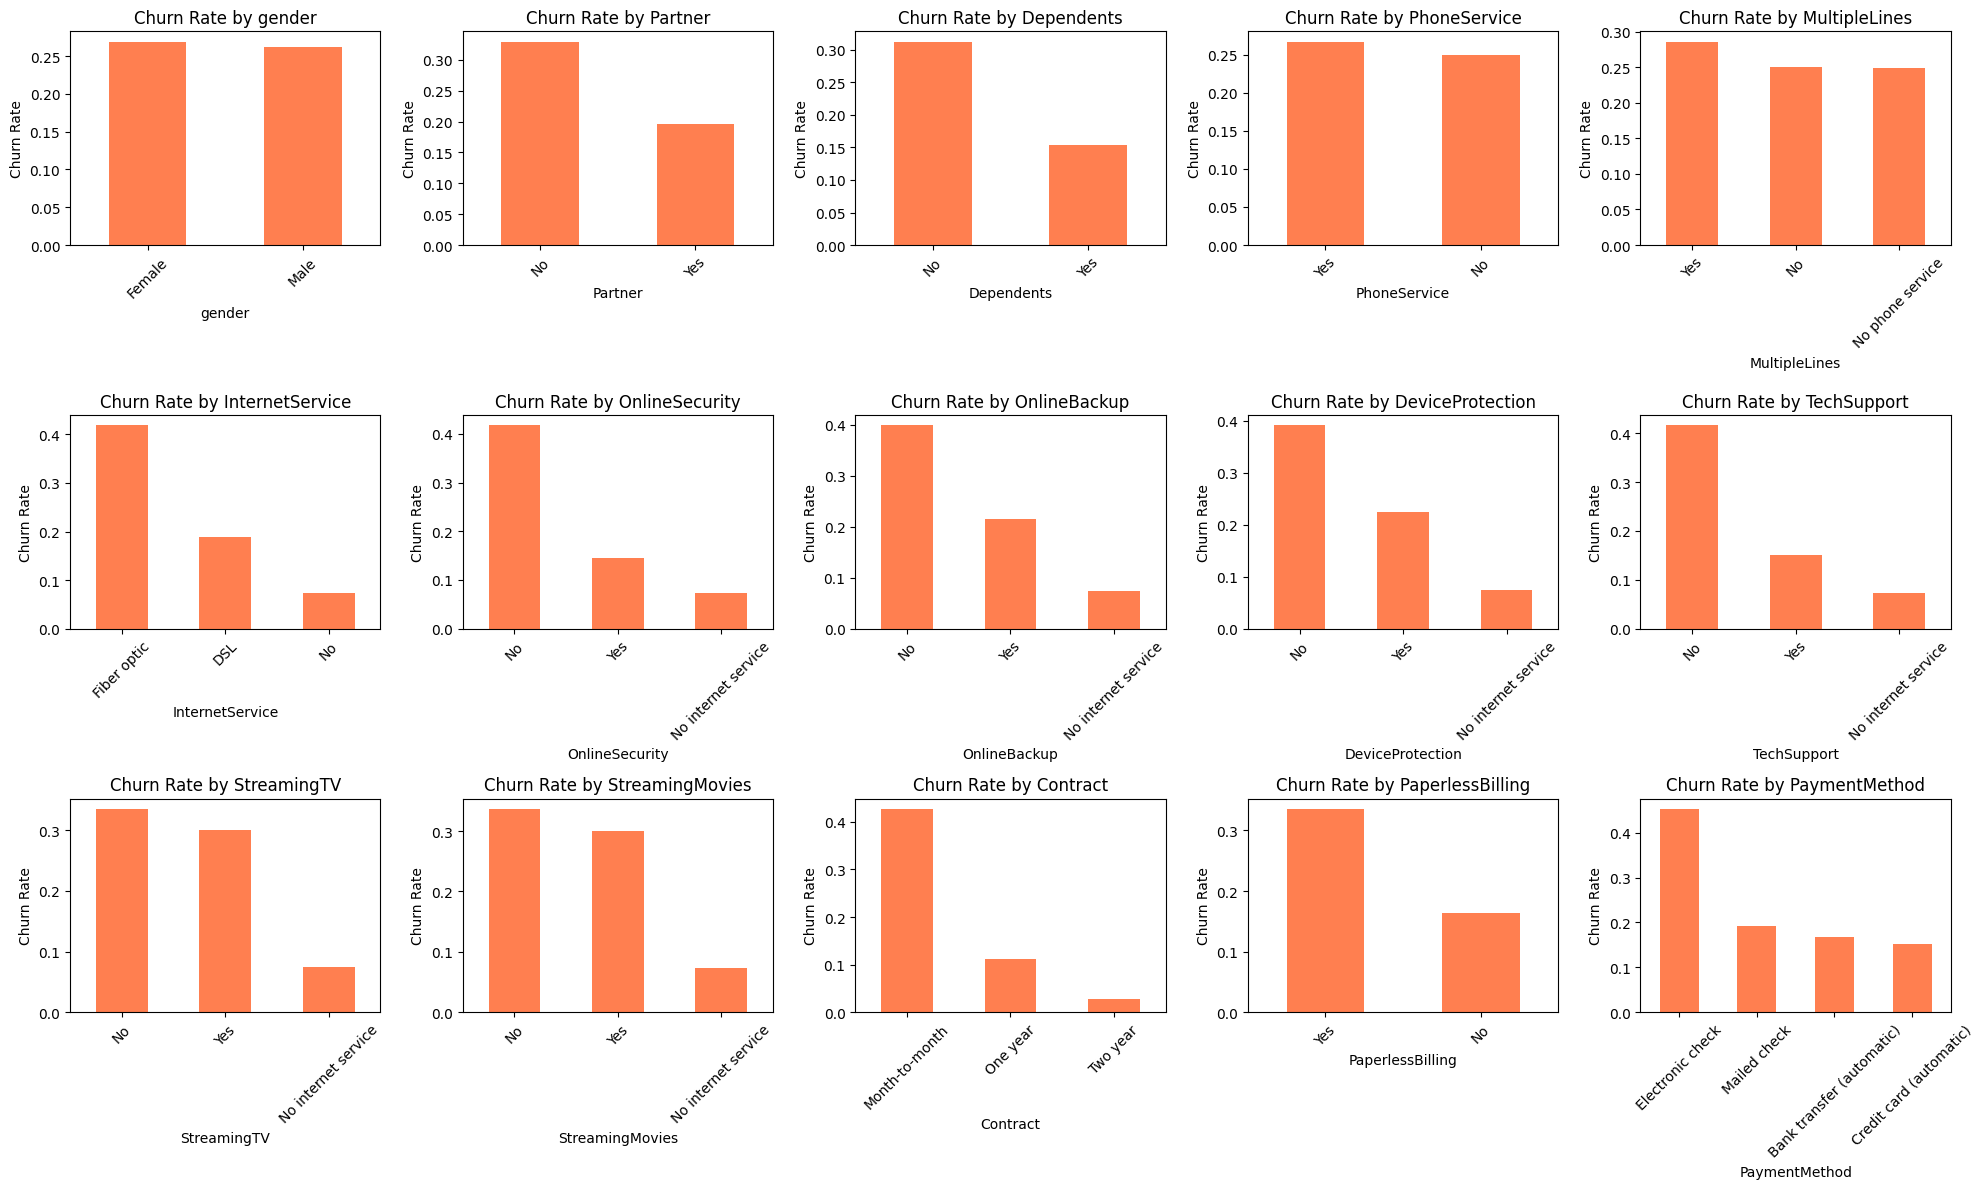

#### 5.3 关键洞察
> **高危画像**：Month-to-month 合约 + Fiber optic + Electronic check 支付 + 无在线安全/技术支持 + 低 tenure + 高月费。这类用户缺乏绑定关系，且对高价服务体验敏感。Month-to-month + Fiber optic + Electronic check 组合的用户共 1,307 人（占比 18.6%），流失率高达 60.4%，

---

### 六、数据相关性

- `TotalCharges` 与 `tenure` 相关系数极高（> 0.8），存在**多重共线性**风险，后续考虑二选一或构造衍生特征（如 `AvgMonthlyCharge = TotalCharges / tenure`）。
- `SeniorCitizen` 与流失呈弱正相关，老年用户流失倾向略高。
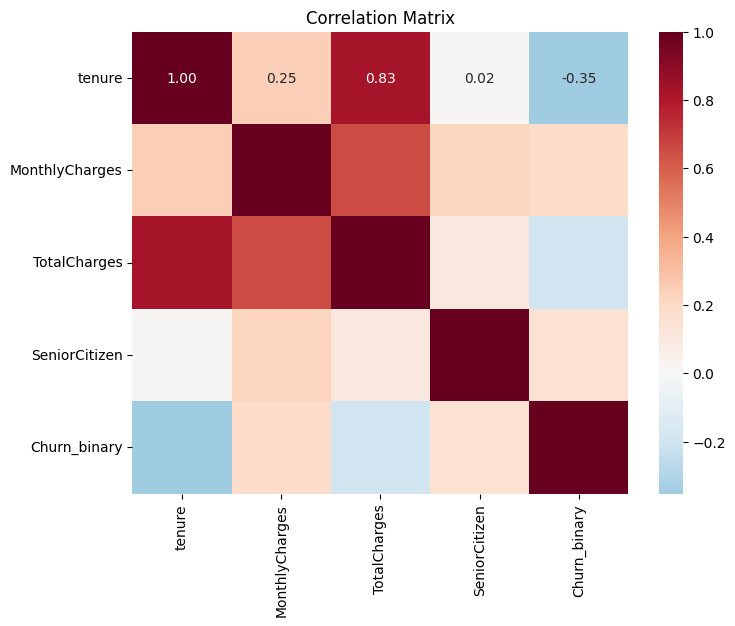
---

### 七、结论与建议

#### 7.1 EDA 核心结论
| 发现| 数据依据         | 性质      |
| ------------- | ------------------------------------------------------------------------------------------------ | ------- |
| 目标变量存在轻度不平衡   | Churn=Yes 占比 26.6%，Churn=No 占比 73.4%                                                             | 描述性统计   |
| 合约类型与流失率差异最大  | Month-to-month 用户流失率约 42.7%，Two year 用户约 3.0%，差异达 39.7 个百分点                                      | 单变量关联   |
| 支付方式存在明显分层    | 在 Month-to-month + Fiber optic 条件下，Electronic check 用户流失率 60.4%，Credit card (automatic) 用户 41.6% | 多变量交叉   |
| 增值服务开通状态与流失相关 | 未开通 OnlineSecurity / TechSupport 的用户流失率（约 41.5%）约为开通用户（约 14.6%）的 2.8 倍                           | 单变量关联   |
| 在网时长与累计消费高度相关 | TotalCharges 与 tenure 相关系数 > 0.8                                                                 | 多重共线性风险 |
| 新用户集中流失       | tenure < 12 个月的用户在流失群体中占比显著偏高                                                                    | 分布观察    |

#### 7.2 建模阶段注意
| 问题       | 现状                                                            | 建议处理方式                                                     |
| -------- | ------------------------------------------------------------- | ---------------------------------------------------------- |
| 多重共线性    | TotalCharges 与 tenure 相关系数 > 0.8                              | 考虑剔除其一，或构造衍生特征（如 AvgMonthlyCharge = TotalCharges / tenure） |
| 类别不平衡    | 正负样本比约 2.7:1                                                  | 训练集可考虑 SMOTE / 类别权重调整；评估指标优先使用 F1、AUC-PR，而非单纯准确率           |
| 高基数类别    | PaymentMethod 包含 4 个类别，InternetService 包含 3 个类别               | 常规 One-Hot 编码即可，无需降基                                       |
| 数值变量尺度差异 | tenure（0-72）与 MonthlyCharges（18-118）量纲不同                      | 建模前需标准化 / 归一化                                              |
| 潜在混杂     | 多个类别变量间可能存在交互效应（如 Contract × InternetService × PaymentMethod） | 考虑引入交互项或基于树模型的自动特征组合                                       |

#### 7.3 数据局限性说明

- 截面数据：本数据集为单时间截面快照，无法观察用户行为随时间的动态变化，也难以确定流失的精确时点。
- 数据集不包含年龄、收入、职业、地区等 demographics 信息，仅能从服务订阅行为推断用户特征，无法构建完整用户画像，也不支持基于人口属性的细分分析。这个数据只能做行为描述（选了什么套餐、用什么支付、在网多久），不能做画像归因（是什么样的人、为什么这样选）。



In [67]:
import numpy as np
import pandas as pd
from pathlib import Path

data_path=Path("../data/raw/telco_customer_churn.csv")
df=pd.read_csv(data_path)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [68]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [69]:
df.shape

(7043, 21)

In [70]:
df.info() #内部调用print

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [71]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [72]:
# TotalCharges列转为数字
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce') 
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [73]:
# 用MonthlyCharge填充首月用户的TotalCharges
print(df.loc[df['TotalCharges'].isna(),'tenure'])
df.loc[df['TotalCharges'].isna(),'TotalCharges']=df.loc[df['TotalCharges'].isna(),'MonthlyCharges']
df['TotalCharges'].info() #确认
print(f"缺失值:{df['TotalCharges'].isna().sum()}")

488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64
<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB
缺失值:0


In [ ]:
#检查customerID是否有重复，且检查前先清洗ID里带着的空格,以及正则表达式
import re
df['customerID']=df['customerID'].str.strip()
pattern=r'^[0-9]{4}-[A-Z]{5}$'
invalid_ids=df[~df['customerID'].str.match(pattern)]
print(f'不符合标准格式的ID数量:{len(invalid_ids)}')
duplicated_count=df['customerID'].duplicated().sum()
if duplicated_count>0:
    print(f'清洗后发现:{duplicated_count}个重复的ID,已去重。')
    df=df.drop_duplicates(subset=['customerID'],keep='first')
else:
    print('清洗后ID唯一。')




不符合标准格式的ID数量:0
清洗后ID唯一。


In [75]:
#选出所有object类型的列（不包含customerID）
object_cols=df.select_dtypes(include=['object']).columns.tolist()
object_cols.remove('customerID')
object_cols.remove('Churn')
 #去首尾空格
print
for col in object_cols:
    df[col]=df[col].str.strip()
#打印分类列的唯一值
for col in object_cols:
    print(f'{col}的唯一取值：{df[col].unique()}')
print(f"SeniorCitizen的取值:{df['SeniorCitizen'].unique()}")




gender的唯一取值：['Female' 'Male']
Partner的唯一取值：['Yes' 'No']
Dependents的唯一取值：['No' 'Yes']
PhoneService的唯一取值：['No' 'Yes']
MultipleLines的唯一取值：['No phone service' 'No' 'Yes']
InternetService的唯一取值：['DSL' 'Fiber optic' 'No']
OnlineSecurity的唯一取值：['No' 'Yes' 'No internet service']
OnlineBackup的唯一取值：['Yes' 'No' 'No internet service']
DeviceProtection的唯一取值：['No' 'Yes' 'No internet service']
TechSupport的唯一取值：['No' 'Yes' 'No internet service']
StreamingTV的唯一取值：['No' 'Yes' 'No internet service']
StreamingMovies的唯一取值：['No' 'Yes' 'No internet service']
Contract的唯一取值：['Month-to-month' 'One year' 'Two year']
PaperlessBilling的唯一取值：['Yes' 'No']
PaymentMethod的唯一取值：['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
SeniorCitizen的取值:[0 1]


In [76]:
#数值型变量的异常值检测，查看统计摘要
print(df[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']].describe())


       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2279.798992
std         0.368612    24.559481       30.090047   2266.730170
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    398.550000
50%         0.000000    29.000000       70.350000   1394.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


In [77]:
#检查业务逻辑历史总费用TotalCharges和当前月费用MonthlyCharges 的关系
df_check=df.loc[df['tenure']>=1].copy() #独立副本
too_low=df_check[df_check['TotalCharges']<df_check['MonthlyCharges']]
print(f'TotalCharges<MonthlyCharges:{len(too_low)}个')

TotalCharges<MonthlyCharges:0个


Churn分布：
       Count    Ratio
Churn                
No      5174  0.73463
Yes     1869  0.26537


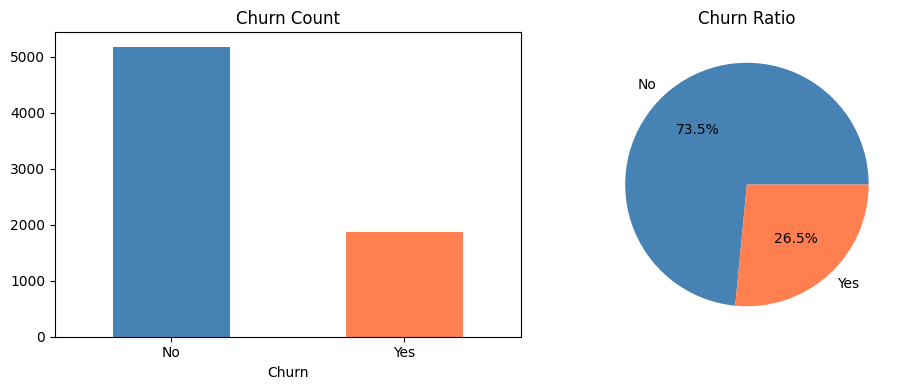

In [78]:
#查看目标变量的Churn分布
import matplotlib.pyplot as plt
churn_counts = df['Churn'].value_counts()
churn_ratio = df['Churn'].value_counts(normalize=True)
print("Churn分布：")
print(pd.DataFrame({'Count':churn_counts,'Ratio':churn_ratio}))
#画图
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Churn Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

churn_ratio.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1].set_title('Churn Ratio')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

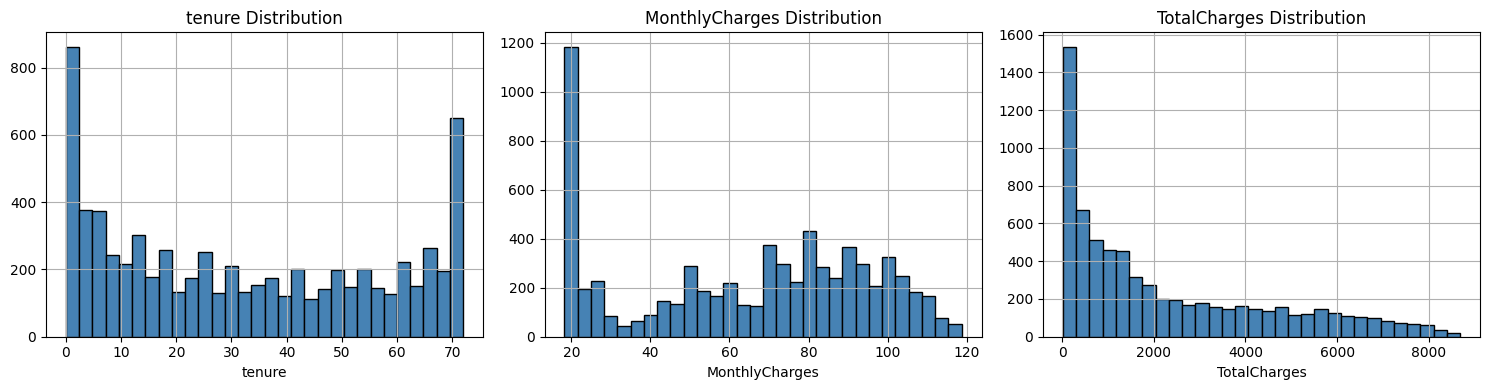

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992
std,24.559481,30.090047,2266.730170
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [79]:
# 数值变量画图
nums_cols=['tenure','MonthlyCharges','TotalCharges']
fig,axes=plt.subplots(1,3,figsize=(15,4))
for i,col in enumerate(nums_cols):
    df[col].hist(bins=30,ax=axes[i],color='steelblue',edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()
df[nums_cols].describe()


tenure分布图发现：有很多新用户和很多老用户


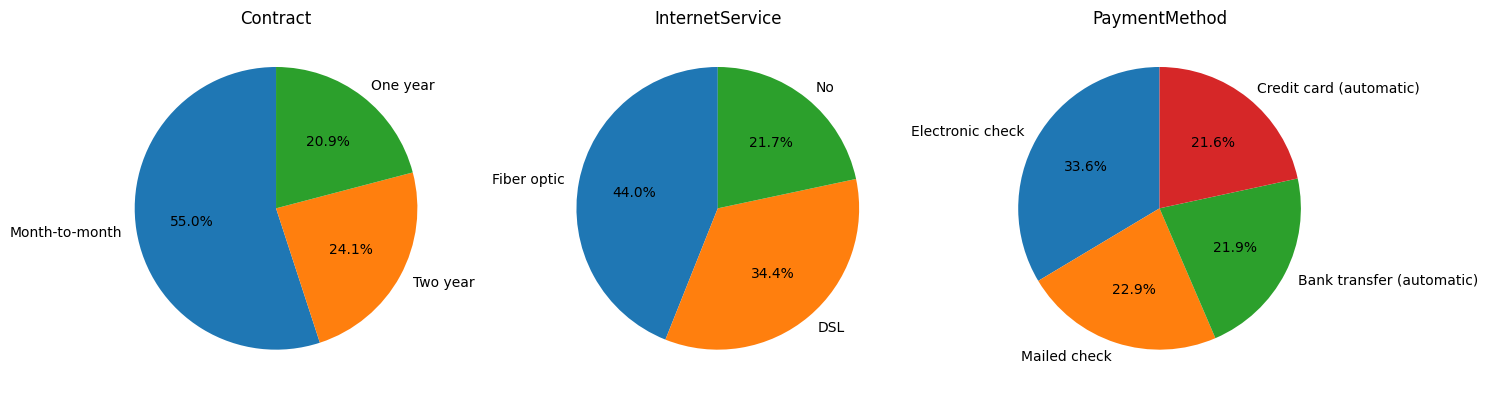

In [85]:
#关键类别型变量分布
import matplotlib.pyplot as plt
cat_cols = ['Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(
        kind='pie', 
        ax=axes[i], 
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

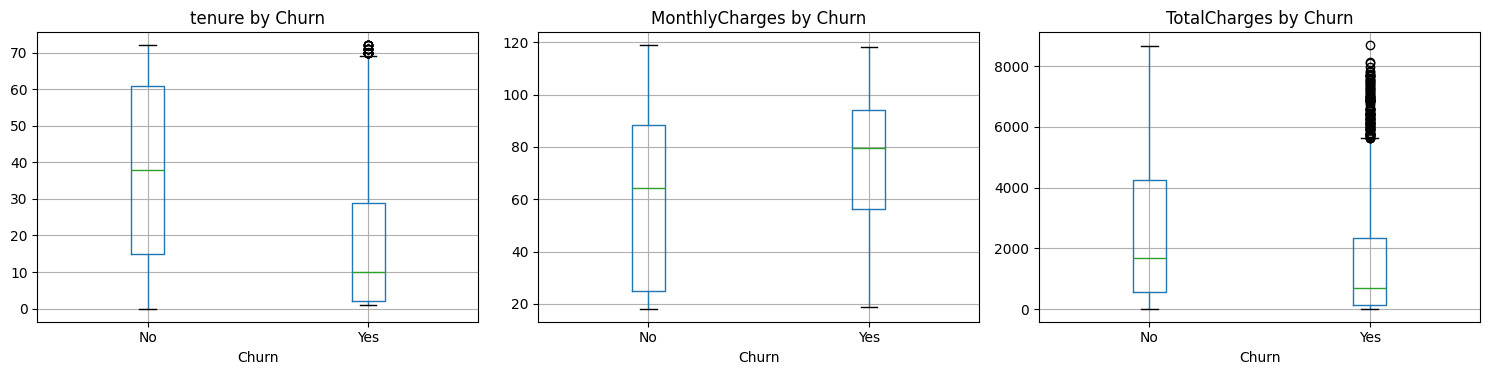

In [80]:
# 数值变量 VS Churn
nums_cols=['tenure','MonthlyCharges','TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(nums_cols):
    # 按 Churn 分组画箱线图
    df.boxplot(column=col, by='Churn', ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn')

plt.suptitle('')  # 去掉 pandas 自动生成的总标题
plt.tight_layout()
plt.show()

In [86]:
# 计算每个类别变量的"最大流失率 - 最小流失率"
# 差异越大，说明这个字段对流失的区分度越强

cat_cols_all = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])

importance = []
for col in cat_cols_all:
    churn_by_group = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    diff = churn_by_group.max() - churn_by_group.min()
    importance.append({'字段': col, '流失率差异': round(diff, 3)})

pd.DataFrame(importance).sort_values('流失率差异', ascending=False)

,字段,流失率差异
12,Contract,0.399
5,InternetService,0.345
6,OnlineSecurity,0.344
9,TechSupport,0.342
7,OnlineBackup,0.325
8,DeviceProtection,0.317
14,PaymentMethod,0.300
11,StreamingMovies,0.263
10,StreamingTV,0.261
13,PaperlessBilling,0.172


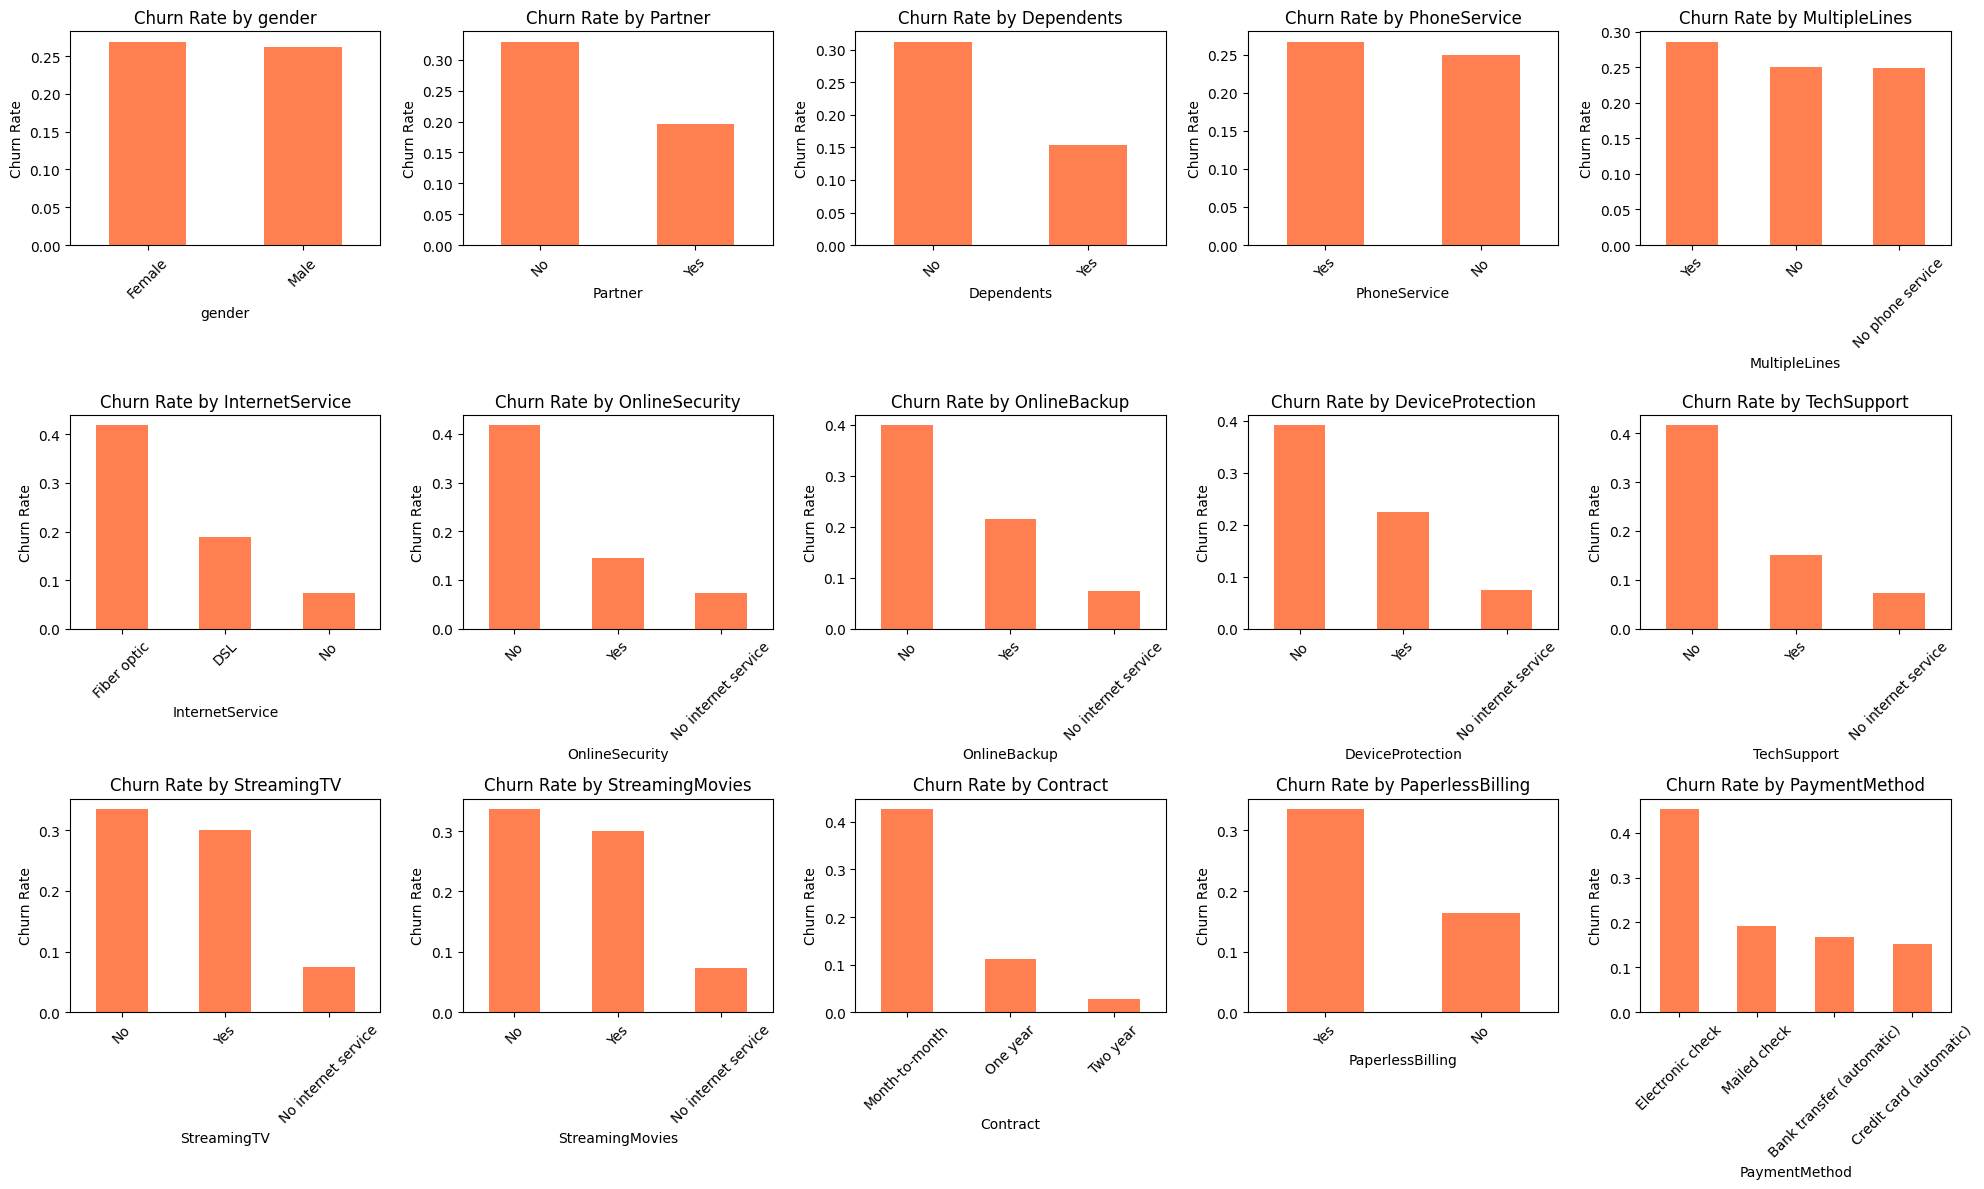

In [87]:
# 类别变量 VS Churn
# 排除 customerID（纯标识符，无业务意义）和 Churn（目标变量本身）
cat_cols_all = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])

fig, axes = plt.subplots(3, 5, figsize=(20, 12))  # 根据实际列数调整
axes = axes.flatten()

for i, col in enumerate(cat_cols_all):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='coral')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=45)

# 隐藏多余的子图
for j in range(len(cat_cols_all), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

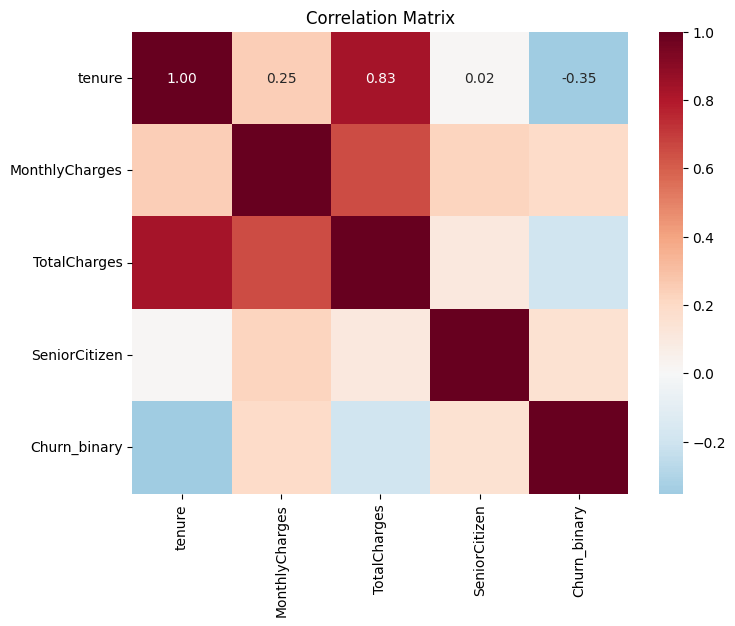

In [82]:
#相关性热力图
import seaborn as sns

# 先把 Churn 转成 0/1，才能算相关
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [83]:
# Contract vs Churn 交叉表
pd.crosstab(df['Contract'], df['Churn'], margins=True)
# 看流失率比例
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [88]:
# 按三个维度分组，看各组合的流失率和人数
combo = df.groupby(['Contract', 'InternetService', 'PaymentMethod'])['Churn'].agg(
    Count='size',
    ChurnRate=lambda x: (x == 'Yes').mean()
).reset_index()

# 只看人数>=30 的组合（避免样本太少）
combo = combo[combo['Count'] >= 30]

# 按流失率排序
print(combo.sort_values('ChurnRate', ascending=False).head(10))

          Contract InternetService              PaymentMethod  Count  \
6   Month-to-month     Fiber optic           Electronic check   1307   
7   Month-to-month     Fiber optic               Mailed check    201   
4   Month-to-month     Fiber optic  Bank transfer (automatic)    327   
5   Month-to-month     Fiber optic    Credit card (automatic)    293   
2   Month-to-month             DSL           Electronic check    474   
3   Month-to-month             DSL               Mailed check    367   
1   Month-to-month             DSL    Credit card (automatic)    185   
18        One year     Fiber optic           Electronic check    196   
11  Month-to-month              No               Mailed check    325   
8   Month-to-month              No  Bank transfer (automatic)     65   

    ChurnRate  
6    0.603673  
7    0.507463  
4    0.455657  
5    0.416382  
2    0.405063  
3    0.307902  
1    0.270270  
18   0.260204  
11   0.206154  
8    0.200000  
